# Deteksi Outlier Konsentrasi 4 Polutan (CH4, CO, NO2, SO2) Menggunakan Metode Interquartile Range (IQR)

**Dataset**: `data/csv/Hasil Polutan.csv` (Rentang 1 - 365 Hari Pengamatan: 24 Agustus 2025 s.d. 23 Agustus 2026)  
**Tujuan**: Melakukan identifikasi dan pembersihan data pencilan (*outliers*) pada 4 polutan udara (`CH4`, `CO`, `NO2`, `SO2`) menggunakan metode **Interquartile Range (IQR)** dengan aturan pagar Tukey ($1.5 \times IQR$), menyajikan visualisasi runtun waktu komparatif lengkap dengan zona pagar batas (*fences*), menyusun **tabel urutan data outlier** secara terstruktur di bawah visualisasi (kronologis dan tingkat keparahan deviasi), serta mengekspor dataset bersih terstandarisasi untuk tahapan penambalan nilai kosong (*missing value*).

## Tahap 1: Memuat Data dan Eksplorasi Profil 4 Polutan (Hari 1 - 365)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Pemuatan dataset mentah hasil observasi 4 polutan
input_path = "../data/csv/Hasil Polutan.csv"
if not os.path.exists(input_path):
    input_path = "data/csv/Hasil Polutan.csv"

df_raw = pd.read_csv(input_path)

# 2. Pembatasan tepat pada rentang 365 hari pengamatan pertama
df = df_raw.iloc[:365].copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])

pollutants = ['CH4', 'CO', 'NO2', 'SO2']

# 3. Profil ketersediaan data 4 polutan
profil_data = []
for p in pollutants:
    n_valid = df[p].notna().sum()
    n_missing = df[p].isna().sum()
    pct_valid = (n_valid / len(df)) * 100
    pct_missing = (n_missing / len(df)) * 100
    profil_data.append({
        'Polutan': p,
        'Total Hari': len(df),
        'Data Valid (Hari)': n_valid,
        'Persentase Valid (%)': f"{pct_valid:.2f}%",
        'Missing Values (Hari)': n_missing,
        'Persentase Missing (%)': f"{pct_missing:.2f}%"
    })

df_profil = pd.DataFrame(profil_data)

print("=== PROFIL DATASET 4 POLUTAN 1 TAHUN (HARI 1 - 365) ===")
print(f"Total Baris Data        : {len(df)} hari")
print(f"Rentang Tanggal         : {df['tanggal'].min().strftime('%Y-%m-%d')} s.d. {df['tanggal'].max().strftime('%Y-%m-%d')}")
display(df_profil)

print("\n--- 5 Baris Pertama Dataset ---")
display(df.head())

=== PROFIL DATASET 4 POLUTAN 1 TAHUN (HARI 1 - 365) ===
Total Baris Data        : 365 hari
Rentang Tanggal         : 2025-08-24 s.d. 2026-08-23


,Polutan,Total Hari,Data Valid (Hari),Persentase Valid (%),Missing Values (Hari),Persentase Missing (%)
0,CH4,365,27,7.40%,338,92.60%
1,CO,365,236,64.66%,129,35.34%
2,NO2,365,218,59.73%,147,40.27%
3,SO2,365,249,68.22%,116,31.78%



--- 5 Baris Pertama Dataset ---


,tanggal,CH4,CO,NO2,SO2
0,2025-08-24,1850.206787,0.032369,0.000030,0.000544
1,2025-08-25,1867.289429,0.029644,0.000040,0.000182
2,2025-08-26,NaN,NaN,0.000046,-0.000258
3,2025-08-27,NaN,0.028471,NaN,0.000107
4,2025-08-28,NaN,0.024230,0.000029,-0.000066


## Tahap 2: Eksplorasi Statistik Deskriptif dan Visualisasi Distribusi Awal (4 Polutan)

=== TABEL PARAMETER STATISTIK DESKRIPTIF & PAGAR IQR 4 POLUTAN ===


,Polutan,Jumlah Valid,Mean (μ),Std Dev (σ),Median (Q2),Q1 (25%),Q3 (75%),IQR,Batas Bawah (Q1-1.5*IQR),Batas Atas (Q3+1.5*IQR),Min,Max,Skewness,Kurtosis
0,CH4,27,1.886025e+03,1.988513e+01,1.886851e+03,1.879476e+03,1.902061e+03,2.258516e+01,1.845599e+03,1.935939e+03,1.841516e+03,1.916853e+03,-0.7108,-0.0068
1,CO,236,2.882526e-02,3.180524e-03,2.864418e-02,2.673603e-02,3.056449e-02,3.828462e-03,2.099334e-02,3.630719e-02,2.048735e-02,4.421752e-02,+0.7032,+1.9610
2,NO2,218,3.555625e-05,2.403490e-05,3.145000e-05,2.322500e-05,4.235000e-05,1.912500e-05,-5.462500e-06,7.103750e-05,5.230000e-06,2.463840e-04,+3.9244,+27.9416
3,SO2,249,6.583455e-05,2.032376e-04,5.170000e-05,-5.500000e-05,1.706310e-04,2.256310e-04,-3.934465e-04,5.090775e-04,-5.177910e-04,8.077910e-04,+0.4368,+1.4624


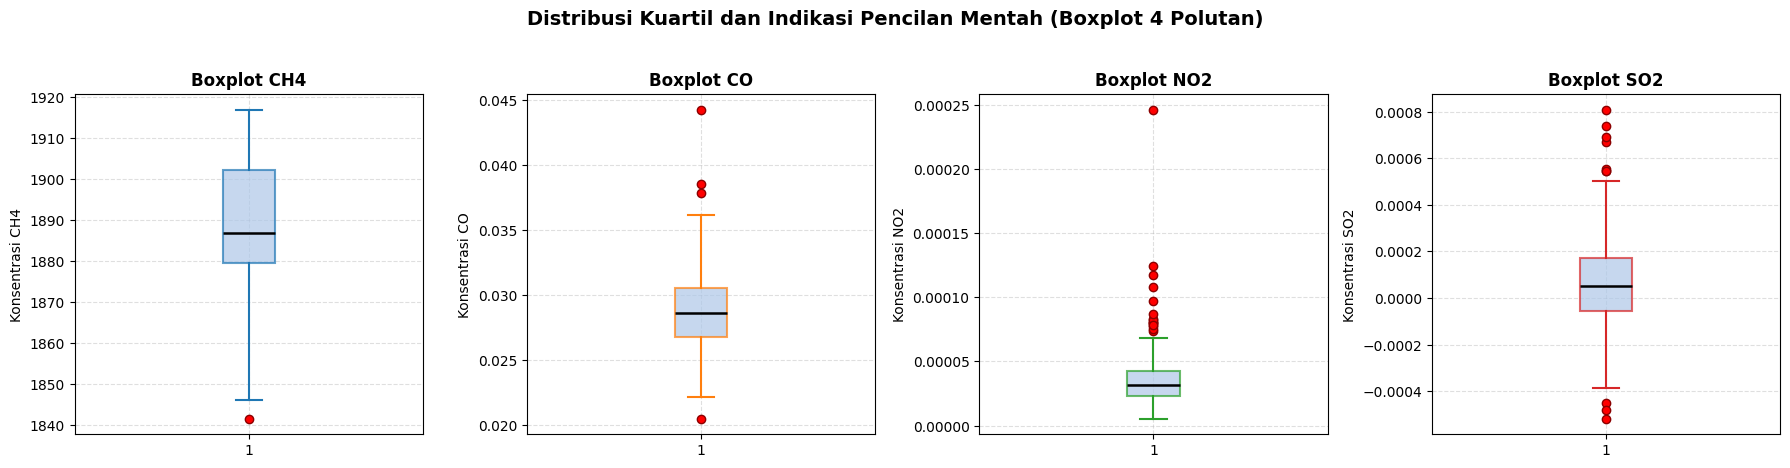

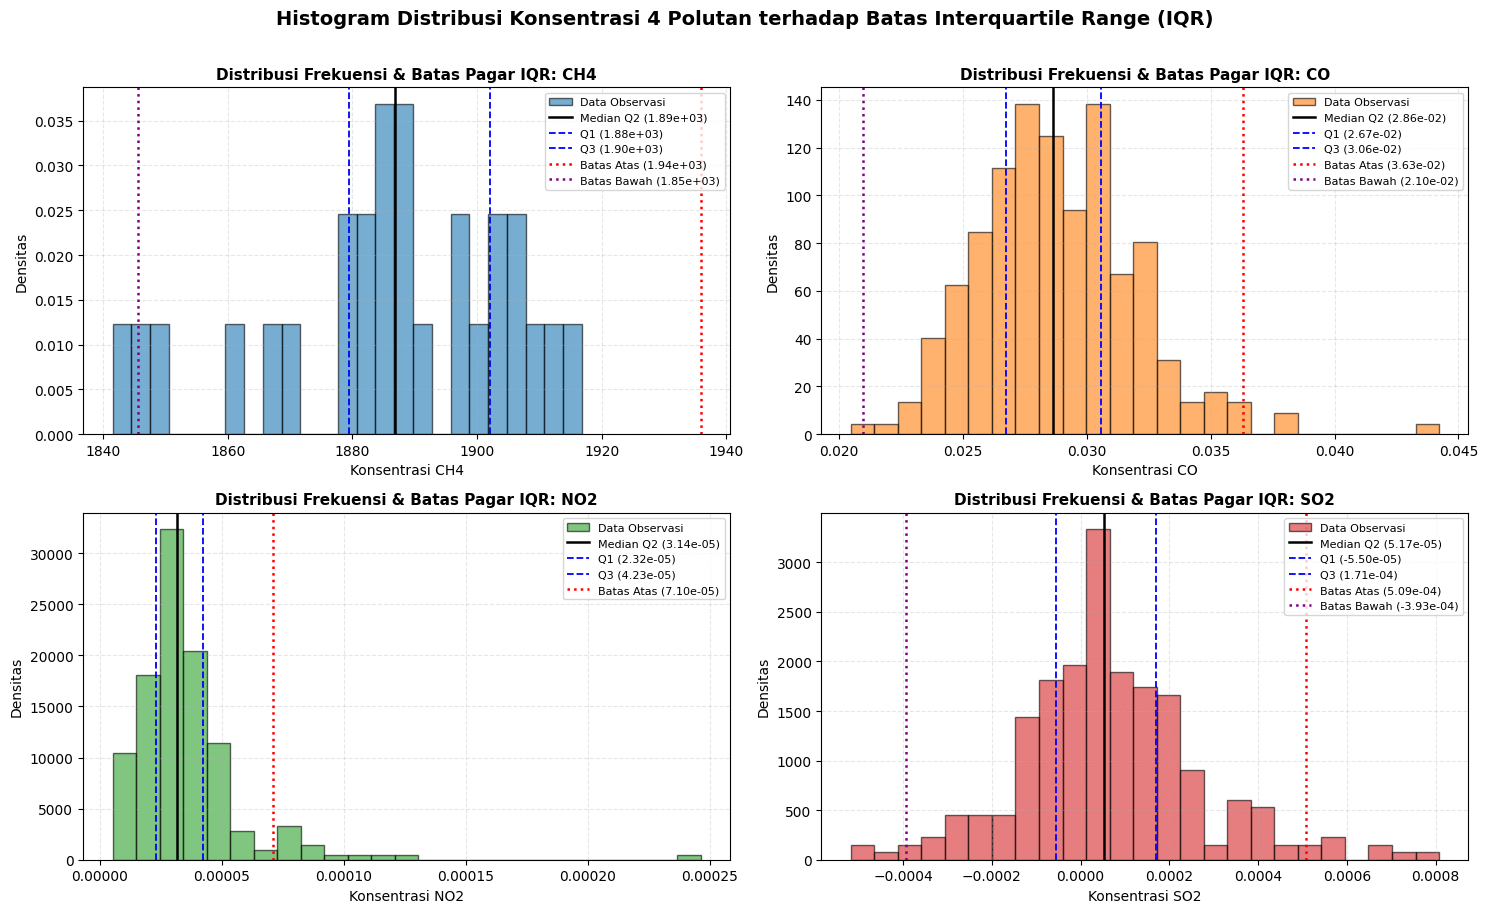

In [2]:
# 1. Komputasi Parameter Statistik Deskriptif & Kuartil 4 Polutan
stats_summary = []
for p in pollutants:
    s = df[p].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    stats_summary.append({
        'Polutan': p,
        'Jumlah Valid': len(s),
        'Mean (μ)': f"{s.mean():.6e}",
        'Std Dev (σ)': f"{s.std():.6e}",
        'Median (Q2)': f"{s.median():.6e}",
        'Q1 (25%)': f"{q1:.6e}",
        'Q3 (75%)': f"{q3:.6e}",
        'IQR': f"{iqr:.6e daylight}" if False else f"{iqr:.6e}",
        'Batas Bawah (Q1-1.5*IQR)': f"{lower_fence:.6e}",
        'Batas Atas (Q3+1.5*IQR)': f"{upper_fence:.6e}",
        'Min': f"{s.min():.6e}",
        'Max': f"{s.max():.6e}",
        'Skewness': f"{s.skew():+.4f}",
        'Kurtosis': f"{s.kurtosis():+.4f}"
    })

df_stat_all = pd.DataFrame(stats_summary)
print("=== TABEL PARAMETER STATISTIK DESKRIPTIF & PAGAR IQR 4 POLUTAN ===")
display(df_stat_all)

# 2. Visualisasi Boxplot Distribusi 4 Polutan (Tukey's Fences)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, p in enumerate(pollutants):
    s = df[p].dropna()
    bp = axes[i].boxplot(s, patch_artist=True,
                         boxprops=dict(facecolor='#aec7e8', color=box_colors[i], linewidth=1.5, alpha=0.7),
                         whiskerprops=dict(color=box_colors[i], linewidth=1.5),
                         capprops=dict(color=box_colors[i], linewidth=1.5),
                         medianprops=dict(color='black', linewidth=1.8),
                         flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='darkred', markersize=6))
    axes[i].set_title(f'Boxplot {p}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(f'Konsentrasi {p}', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribusi Kuartil dan Indikasi Pencilan Mentah (Boxplot 4 Polutan)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# 3. Visualisasi Histogram Frekuensi dan Penanda Pagar IQR
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, p in enumerate(pollutants):
    s = df[p].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    median_val = s.median()
    
    axes[i].hist(s, bins=25, density=True, alpha=0.6, color=box_colors[i], edgecolor='black', label='Data Observasi')
    axes[i].axvline(median_val, color='black', linestyle='-', linewidth=1.8, label=f'Median Q2 ({median_val:.2e})')
    axes[i].axvline(q1, color='blue', linestyle='--', linewidth=1.3, label=f'Q1 ({q1:.2e})')
    axes[i].axvline(q3, color='blue', linestyle='--', linewidth=1.3, label=f'Q3 ({q3:.2e})')
    axes[i].axvline(ub, color='red', linestyle=':', linewidth=1.8, label=f'Batas Atas ({ub:.2e})')
    if lb >= (s.min() - 0.1 * abs(s.min())):
        axes[i].axvline(lb, color='purple', linestyle=':', linewidth=1.8, label=f'Batas Bawah ({lb:.2e})')
        
    axes[i].set_title(f'Distribusi Frekuensi & Batas Pagar IQR: {p}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'Konsentrasi {p}', fontsize=10)
    axes[i].set_ylabel('Densitas', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].legend(fontsize=8, loc='upper right')

plt.suptitle('Histogram Distribusi Konsentrasi 4 Polutan terhadap Batas Interquartile Range (IQR)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Tahap 3: Deteksi Outlier Menggunakan Metode Interquartile Range (IQR / Tukey's Fences)

Pada tahapan ini, diterapkan algoritma **Interquartile Range (IQR)** dengan aturan pagar Tukey (*Tukey's Fences*) dengan faktor pengali $1.5$:

$$\text{Batas Bawah (Lower Fence)} = Q_1 - 1.5 \times IQR$$
$$\text{Batas Atas (Upper Fence)} = Q_3 + 1.5 \times IQR$$

Di mana:
- $Q_1$ adalah Kuartil Bawah (Persentil ke-25).
- $Q_3$ adalah Kuartil Atas (Persentil ke-75).
- $IQR = Q_3 - Q_1$ adalah Rentang Antarkuartil yang memuat 50% data di area tengah.

### Keunggulan Metode IQR Dibandingkan Z-Score:
1. **Non-Parametrik & Bebas Asumsi Distribusi**: IQR tidak mensyaratkan data harus berdistribusi normal (Gaussian), sangat cocok untuk data konsentrasi polutan yang cenderung miring (*skewed*).
2. **Kekebalan terhadap Efek Penyamaran (*Masking Effect*)**: Titik pencilan yang sangat ekstrem tidak dapat mendistorsi kuartil dan median secara drastis, berbeda dengan rata-rata ($\mu$) dan simpangan baku ($\sigma$) pada Z-Score yang sangat sensitif terhadap ekstremitas nilai.
3. **Derajat Keparahan Outlier Berbasis IQR**: Jarak relatif suatu pencilan diukur berdasarkan kelipatan IQR terhadap kuartil terdekat:
   $$k = \begin{cases} \frac{x_i - Q_3}{IQR}, & x_i > Q_3 + 1.5 \times IQR \text{ (Pencilan Atas)} \\ \frac{Q_1 - x_i}{IQR}, & x_i < Q_1 - 1.5 \times IQR \text{ (Pencilan Bawah)} \end{cases}$$
   Titik dengan $k > 3.0$ diklasifikasikan sebagai *pencilan sangat ekstrem (extreme outlier)*.

In [3]:
# DETEKSI OUTLIER METODE IQR (1.5 * IQR) UNTUK 4 POLUTAN
all_outliers_records = []
iqr_params = {}

print("=" * 85)
print("MEMULAI PROSES DETEKSI OUTLIER METODE INTERQUARTILE RANGE (IQR) UNTUK 4 POLUTAN")
print("Aturan Pagar Tukey: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]")
print("=" * 85)

for pol in pollutants:
    valid_series = df[pol].dropna()
    q1 = valid_series.quantile(0.25)
    q3 = valid_series.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    
    iqr_params[pol] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower_Fence': lower_fence, 'Upper_Fence': upper_fence
    }
    
    outliers = valid_series[(valid_series < lower_fence) | (valid_series > upper_fence)]
    pol_records = []
    
    print(f"\n>>> POLUTAN: {pol} <<<")
    print(f"  Jumlah Data Valid    : {len(valid_series)} hari")
    print(f"  Q1 (25%)             : {q1:.8e}")
    print(f"  Q3 (75%)             : {q3:.8e}")
    print(f"  IQR (Q3 - Q1)        : {iqr:.8e}")
    print(f"  Batas Bawah Pagar    : {lower_fence:.8e}")
    print(f"  Batas Atas Pagar     : {upper_fence:.8e}")
    print(f"  Outlier Ditemukan    : {len(outliers)} titik")
    
    for idx in outliers.index:
        tgl = df.loc[idx, 'tanggal'].strftime('%Y-%m-%d')
        val = df.loc[idx, pol]
        
        if val > upper_fence:
            kategori = 'Pencilan Atas (Tinggi)'
            deviasi_iqr = (val - q3) / iqr
            selisih_batas = val - upper_fence
        else:
            kategori = 'Pencilan Bawah (Rendah)'
            deviasi_iqr = (q1 - val) / iqr
            selisih_batas = lower_fence - val
            
        record = {
            'Polutan': pol,
            'Metode': 'IQR (1.5x)',
            'Index': idx,
            'Hari_Ke': idx + 1,
            'Tanggal': tgl,
            'Nilai': val,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Batas_Bawah': lower_fence,
            'Batas_Atas': upper_fence,
            'Deviasi_IQR': deviasi_iqr,
            'Selisih_Batas': selisih_batas,
            'Kategori': kategori
        }
        pol_records.append(record)
        all_outliers_records.append(record)
        print(f"    * [Hari ke-{idx+1:3d} | {tgl}] Nilai = {val:.6e} | Deviasi = {deviasi_iqr:.2f}×IQR | Selisih = {selisih_batas:+.3e} ({kategori})")

print("\n" + "=" * 85)
print(f"TOTAL SELURUH OUTLIER TERDETEKSI DARI 4 POLUTAN DENGAN METODE IQR: {len(all_outliers_records)} TITIK")
print("=" * 85)
for p in pollutants:
    sub_count = len([r for r in all_outliers_records if r['Polutan'] == p])
    print(f"- {p:5}: {sub_count:2d} outlier")

MEMULAI PROSES DETEKSI OUTLIER METODE INTERQUARTILE RANGE (IQR) UNTUK 4 POLUTAN
Aturan Pagar Tukey: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

>>> POLUTAN: CH4 <<<
  Jumlah Data Valid    : 27 hari
  Q1 (25%)             : 1.87947625e+03
  Q3 (75%)             : 1.90206141e+03
  IQR (Q3 - Q1)        : 2.25851640e+01
  Batas Bawah Pagar    : 1.84559850e+03
  Batas Atas Pagar     : 1.93593916e+03
  Outlier Ditemukan    : 1 titik
    * [Hari ke-300 | 2026-06-19] Nilai = 1.841516e+03 | Deviasi = 1.68×IQR | Selisih = +4.083e+00 (Pencilan Bawah (Rendah))

>>> POLUTAN: CO <<<
  Jumlah Data Valid    : 236 hari
  Q1 (25%)             : 2.67360315e-02
  Q3 (75%)             : 3.05644930e-02
  IQR (Q3 - Q1)        : 3.82846150e-03
  Batas Bawah Pagar    : 2.09933392e-02
  Batas Atas Pagar     : 3.63071853e-02
  Outlier Ditemukan    : 4 titik
    * [Hari ke- 32 | 2025-09-24] Nilai = 3.780002e-02 | Deviasi = 1.89×IQR | Selisih = +1.493e-03 (Pencilan Atas (Tinggi))
    * [Hari ke- 45 | 2025-10-07] Nilai = 4.42175

## Tahap 4: Visualisasi Hasil Deteksi Outlier IQR & Tabel Urutan Data Outlier

Berikut adalah visualisasi deret waktu komparatif 4 polutan udara dengan zona pagar aman (*safe area band* $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$), garis batas pagar atas/bawah, titik anomali ('X'), serta **3 tabel urutan data outlier secara lengkap dan terstruktur tepat di bawah visualisasi**.

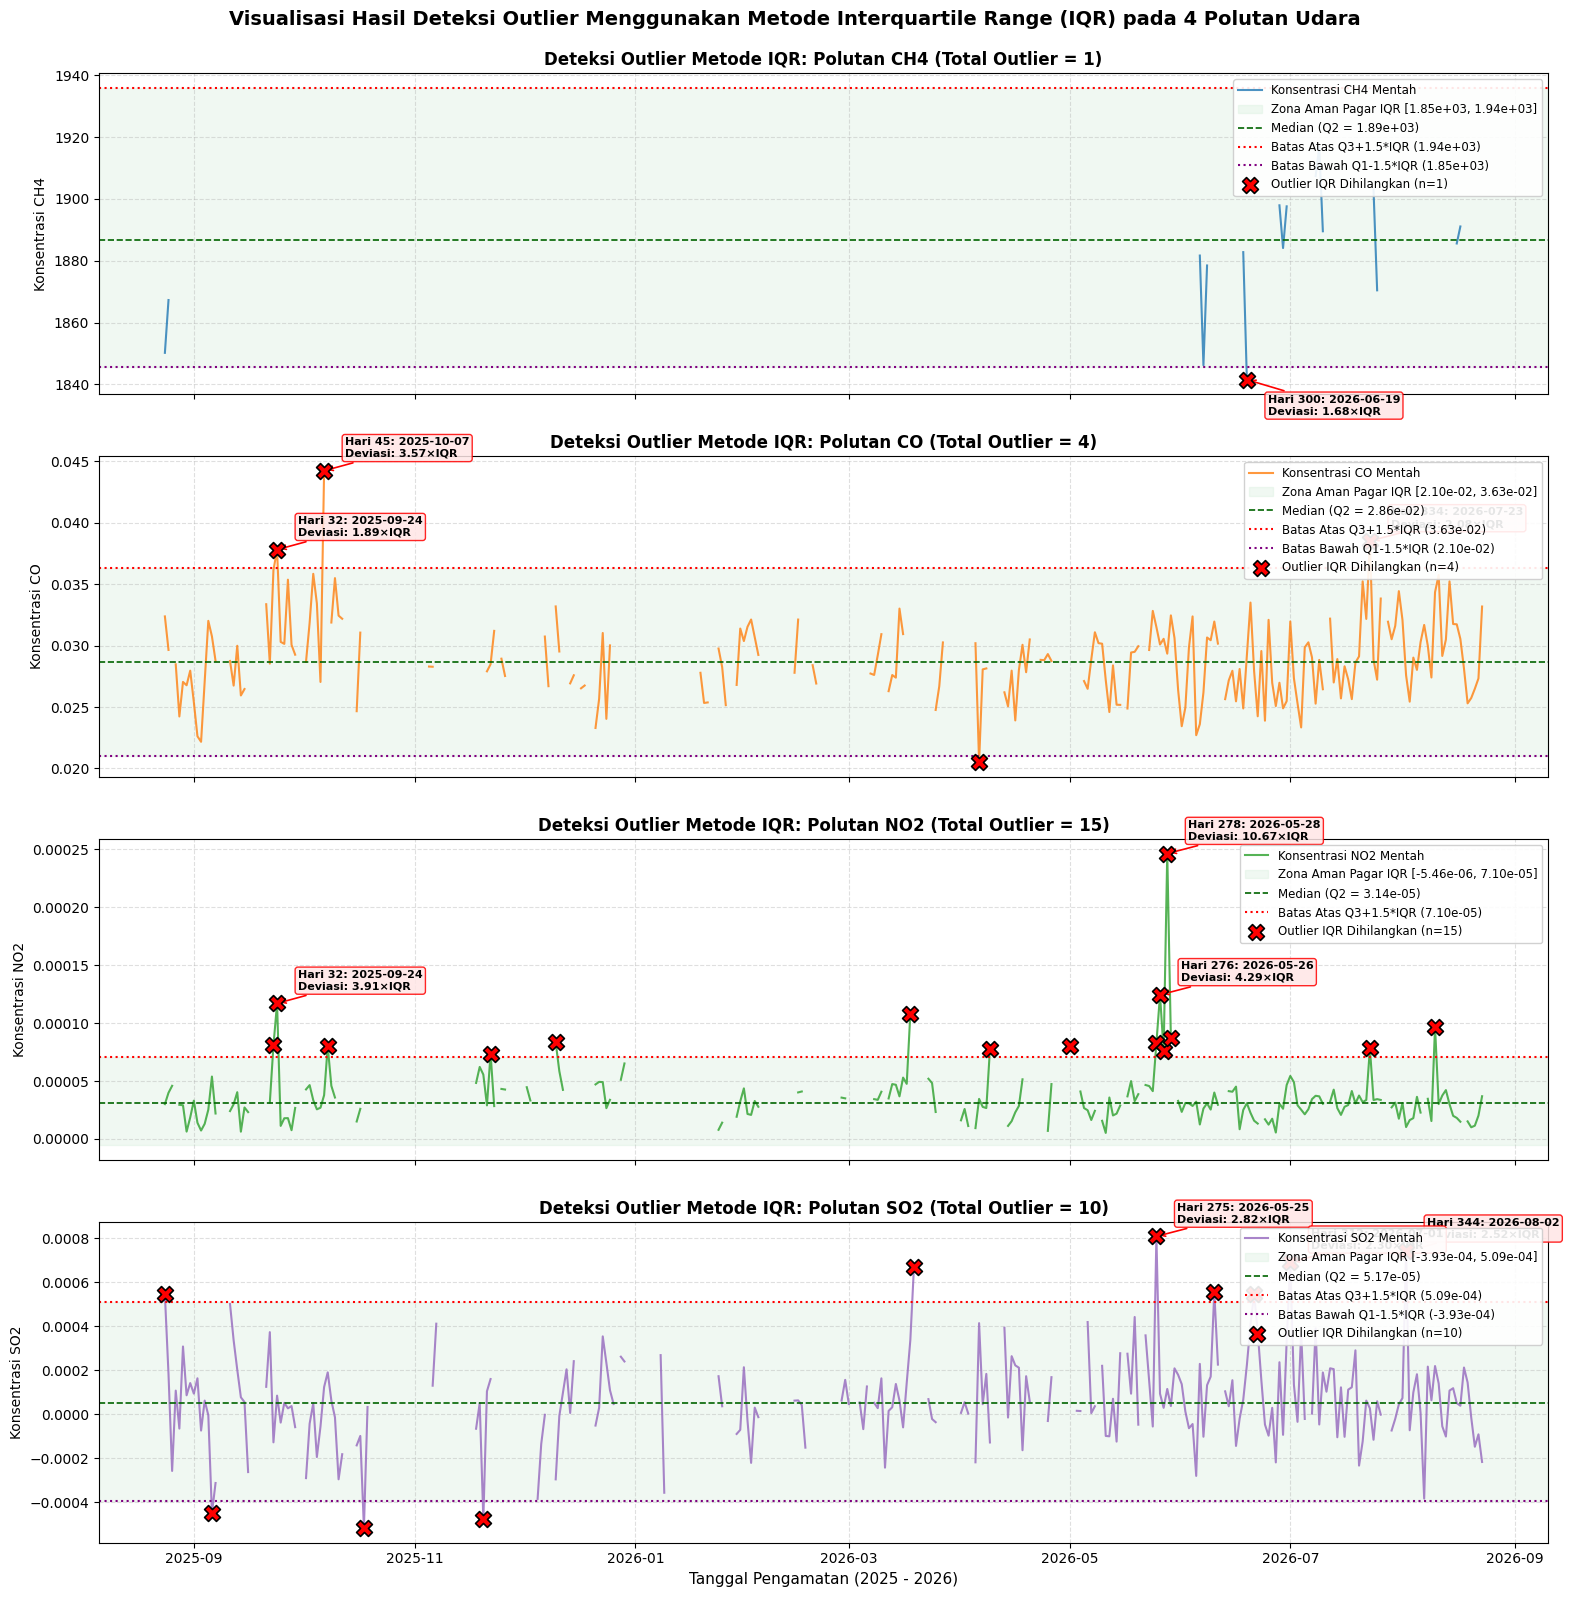

In [4]:
# 1. VISUALISASI HASIL DETEKSI OUTLIER METODE IQR
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
colors_dict = {'CH4': '#1f77b4', 'CO': '#ff7f0e', 'NO2': '#2ca02c', 'SO2': '#9467bd'}

for i, pol in enumerate(pollutants):
    ax = axes[i]
    pol_outliers = [r for r in all_outliers_records if r['Polutan'] == pol]
    outlier_indices = [r['Index'] for r in pol_outliers]
    
    p_info = iqr_params[pol]
    q1 = p_info['Q1']
    q3 = p_info['Q3']
    lb = p_info['Lower_Fence']
    ub = p_info['Upper_Fence']
    median_val = df[pol].dropna().median()
    
    # 1. Garis deret waktu mentah
    ax.plot(df['tanggal'], df[pol], color=colors_dict[pol], linewidth=1.5, alpha=0.8, label=f'Konsentrasi {pol} Mentah')
    
    # 2. Daerah aman batas IQR (Shaded Band)
    ax.axhspan(lb, ub, color='#d4edda', alpha=0.35, label=f'Zona Aman Pagar IQR [{lb:.2e}, {ub:.2e}]')
    
    # 3. Garis batas statistik kuartil & pagar
    ax.axhline(median_val, color='darkgreen', linestyle='--', linewidth=1.2, label=f'Median (Q2 = {median_val:.2e})')
    ax.axhline(ub, color='red', linestyle=':', linewidth=1.5, label=f'Batas Atas Q3+1.5*IQR ({ub:.2e})')
    if lb >= (df[pol].dropna().min() - 0.1 * abs(df[pol].dropna().min())):
        ax.axhline(lb, color='purple', linestyle=':', linewidth=1.5, label=f'Batas Bawah Q1-1.5*IQR ({lb:.2e})')
        
    # 4. Scatter plot titik outlier
    if len(outlier_indices) > 0:
        df_out = df.loc[outlier_indices]
        ax.scatter(df_out['tanggal'], df_out[pol], color='red', marker='X', s=130, edgecolor='black', linewidth=1.2, zorder=5,
                   label=f'Outlier IQR Dihilangkan (n={len(outlier_indices)})')
        
        # Anotasi untuk outlier paling signifikan (deviasi IQR tertinggi)
        top_pol_outliers = sorted(pol_outliers, key=lambda x: x['Deviasi_IQR'], reverse=True)[:3]
        for item in top_pol_outliers:
            ax.annotate(f"Hari {item['Hari_Ke']}: {item['Tanggal']}\nDeviasi: {item['Deviasi_IQR']:.2f}×IQR",
                        xy=(pd.to_datetime(item['Tanggal']), item['Nilai']),
                        xytext=(15, 10 if 'Atas' in item['Kategori'] else -25), textcoords='offset points',
                        fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='#ffe6e6', edgecolor='red', alpha=0.85),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
    else:
        ax.text(df['tanggal'].iloc[len(df)//2], median_val, 'TIDAK DITEMUKAN OUTLIER IQR',
                color='darkblue', fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#e6f2ff', edgecolor='blue', alpha=0.8))
        
    ax.set_title(f'Deteksi Outlier Metode IQR: Polutan {pol} (Total Outlier = {len(outlier_indices)})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Konsentrasi {pol}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=8.5)

axes[-1].set_xlabel('Tanggal Pengamatan (2025 - 2026)', fontsize=11)
plt.suptitle('Visualisasi Hasil Deteksi Outlier Menggunakan Metode Interquartile Range (IQR) pada 4 Polutan Udara', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [5]:
# 2. TABEL URUTAN DATA OUTLIER DI BAWAH VISUALISASI GAMBAR

df_outliers_all = pd.DataFrame(all_outliers_records)

# A. TABEL URUTAN KRONOLOGIS (Berdasarkan Indeks Pengamatan / Hari ke-1 s.d. 365)
df_table_chronological = df_outliers_all.sort_values(by=['Index', 'Polutan']).copy().reset_index(drop=True)
df_table_chronological.index = df_table_chronological.index + 1
df_table_chronological.index.name = 'No'

# Format tampilan numerik yang rapi dan seragam
df_display_chrono = df_table_chronological.copy()
df_display_chrono['Nilai Polutan'] = df_display_chrono['Nilai'].apply(lambda x: f"{x:.6e}")
df_display_chrono['Q1'] = df_display_chrono['Q1'].apply(lambda x: f"{x:.6e}")
df_display_chrono['Q3'] = df_display_chrono['Q3'].apply(lambda x: f"{x:.6e}")
df_display_chrono['IQR'] = df_display_chrono['IQR'].apply(lambda x: f"{x:.6e}")
df_display_chrono['Deviasi (k×IQR)'] = df_display_chrono['Deviasi_IQR'].apply(lambda x: f"{x:.3f}×")
df_display_chrono['Selisih Pagar'] = df_display_chrono['Selisih_Batas'].apply(lambda x: f"{x:+.4e}")
df_display_chrono['Hari ke-'] = df_display_chrono['Hari_Ke']

cols_show_chrono = ['Polutan', 'Hari ke-', 'Tanggal', 'Nilai Polutan', 'Q1', 'Q3', 'IQR', 'Deviasi (k×IQR)', 'Selisih Pagar', 'Kategori']

print("=" * 115)
print("TABEL 1: URUTAN KRONOLOGIS SELURUH DATA OUTLIER METODE IQR (BERDASARKAN HARI KE-1 S.D. 365)")
print(f"Total Baris Outlier: {len(df_display_chrono)} Titik Data")
print("=" * 115)
display(df_display_chrono[cols_show_chrono])

# B. TABEL URUTAN BERDASARKAN TINGKAT KEPARAHAN / DEVIASI IQR TERTINGGI
df_table_severity = df_outliers_all.sort_values(by='Deviasi_IQR', ascending=False).copy().reset_index(drop=True)
df_table_severity.index = df_table_severity.index + 1
df_table_severity.index.name = 'Peringkat Keparahan'

df_display_severity = df_table_severity.copy()
df_display_severity['Nilai Polutan'] = df_display_severity['Nilai'].apply(lambda x: f"{x:.6e}")
df_display_severity['Deviasi (k×IQR)'] = df_display_severity['Deviasi_IQR'].apply(lambda x: f"{x:.3f}×")
df_display_severity['Selisih Pagar'] = df_display_severity['Selisih_Batas'].apply(lambda x: f"{x:+.4e}")
df_display_severity['Hari ke-'] = df_display_severity['Hari_Ke']

cols_show_severity = ['Polutan', 'Hari ke-', 'Tanggal', 'Nilai Polutan', 'Deviasi (k×IQR)', 'Selisih Pagar', 'Kategori']

print("\n" + "=" * 115)
print("TABEL 2: URUTAN OUTLIER BERDASARKAN TINGKAT KEPARAHAN / SIGNIFIKANSI (DEVIASI KELIPATAN IQR TERTINGGI)")
print("=" * 115)
display(df_display_severity[cols_show_severity])

# C. TABEL RINGKASAN REKAPITULASI OUTLIER PER POLUTAN
rekap_data = []
for p in pollutants:
    sub = df_outliers_all[df_outliers_all['Polutan'] == p]
    n_valid = df[p].notna().sum()
    n_out = len(sub)
    pct_out = (n_out / n_valid * 100) if n_valid > 0 else 0
    max_dev = sub['Deviasi_IQR'].max() if n_out > 0 else 0
    tgl_rentang = f"{sub['Tanggal'].min()} s.d. {sub['Tanggal'].max()}" if n_out > 0 else "-"
    p_info = iqr_params[p]
    
    rekap_data.append({
        'Polutan': p,
        'Data Valid Awal': n_valid,
        'Outlier Ditemukan': n_out,
        'Persentase Outlier': f"{pct_out:.2f}%",
        'Data Bersih Tersisa': n_valid - n_out,
        'Batas Bawah (Q1-1.5*IQR)': f"{p_info['Lower_Fence']:.6e}",
        'Batas Atas (Q3+1.5*IQR)': f"{p_info['Upper_Fence']:.6e}",
        'Deviasi IQR Maksimum': f"{max_dev:.3f}×" if n_out > 0 else "-",
        'Rentang Tanggal Outlier': tgl_rentang
    })

df_rekap = pd.DataFrame(rekap_data)
print("\n" + "=" * 115)
print("TABEL 3: REKAPITULASI HASIL DETEKSI OUTLIER METODE IQR PER POLUTAN")
print("=" * 115)
display(df_rekap)

TABEL 1: URUTAN KRONOLOGIS SELURUH DATA OUTLIER METODE IQR (BERDASARKAN HARI KE-1 S.D. 365)
Total Baris Outlier: 30 Titik Data


,Polutan,Hari ke-,Tanggal,Nilai Polutan,Q1,Q3,IQR,Deviasi (k×IQR),Selisih Pagar,Kategori
No,,,,,,,,,,
1,SO2,1,2025-08-24,5.437610e-04,-5.500000e-05,1.706310e-04,2.256310e-04,1.654×,+3.4684e-05,Pencilan Atas (Tinggi)
2,SO2,14,2025-09-06,-4.503410e-04,-5.500000e-05,1.706310e-04,2.256310e-04,1.752×,+5.6894e-05,Pencilan Bawah (Rendah)
3,NO2,31,2025-09-23,8.080000e-05,2.322500e-05,4.235000e-05,1.912500e-05,2.010×,+9.7625e-06,Pencilan Atas (Tinggi)
4,CO,32,2025-09-24,3.780002e-02,2.673603e-02,3.056449e-02,3.828462e-03,1.890×,+1.4928e-03,Pencilan Atas (Tinggi)
5,NO2,32,2025-09-24,1.170790e-04,2.322500e-05,4.235000e-05,1.912500e-05,3.907×,+4.6041e-05,Pencilan Atas (Tinggi)
6,CO,45,2025-10-07,4.421752e-02,2.673603e-02,3.056449e-02,3.828462e-03,3.566×,+7.9103e-03,Pencilan Atas (Tinggi)
7,NO2,46,2025-10-08,8.010000e-05,2.322500e-05,4.235000e-05,1.912500e-05,1.974×,+9.0625e-06,Pencilan Atas (Tinggi)
8,SO2,56,2025-10-18,-5.177910e-04,-5.500000e-05,1.706310e-04,2.256310e-04,2.051×,+1.2434e-04,Pencilan Bawah (Rendah)
9,SO2,89,2025-11-20,-4.784350e-04,-5.500000e-05,1.706310e-04,2.256310e-04,1.877×,+8.4988e-05,Pencilan Bawah (Rendah)



TABEL 2: URUTAN OUTLIER BERDASARKAN TINGKAT KEPARAHAN / SIGNIFIKANSI (DEVIASI KELIPATAN IQR TERTINGGI)


,Polutan,Hari ke-,Tanggal,Nilai Polutan,Deviasi (k×IQR),Selisih Pagar,Kategori
Peringkat Keparahan,,,,,,,
1,NO2,278,2026-05-28,2.463840e-04,10.668×,+1.7535e-04,Pencilan Atas (Tinggi)
2,NO2,276,2026-05-26,1.244530e-04,4.293×,+5.3416e-05,Pencilan Atas (Tinggi)
3,NO2,32,2025-09-24,1.170790e-04,3.907×,+4.6041e-05,Pencilan Atas (Tinggi)
4,CO,45,2025-10-07,4.421752e-02,3.566×,+7.9103e-03,Pencilan Atas (Tinggi)
5,NO2,207,2026-03-18,1.082670e-04,3.447×,+3.7229e-05,Pencilan Atas (Tinggi)
6,NO2,352,2026-08-10,9.680000e-05,2.847×,+2.5762e-05,Pencilan Atas (Tinggi)
7,SO2,275,2026-05-25,8.077910e-04,2.824×,+2.9871e-04,Pencilan Atas (Tinggi)
8,SO2,344,2026-08-02,7.403350e-04,2.525×,+2.3126e-04,Pencilan Atas (Tinggi)
9,NO2,279,2026-05-29,8.710000e-05,2.340×,+1.6063e-05,Pencilan Atas (Tinggi)



TABEL 3: REKAPITULASI HASIL DETEKSI OUTLIER METODE IQR PER POLUTAN


,Polutan,Data Valid Awal,Outlier Ditemukan,Persentase Outlier,Data Bersih Tersisa,Batas Bawah (Q1-1.5*IQR),Batas Atas (Q3+1.5*IQR),Deviasi IQR Maksimum,Rentang Tanggal Outlier
0,CH4,27,1,3.70%,26,1.845599e+03,1.935939e+03,1.681×,2026-06-19 s.d. 2026-06-19
1,CO,236,4,1.69%,232,2.099334e-02,3.630719e-02,3.566×,2025-09-24 s.d. 2026-07-23
2,NO2,218,15,6.88%,203,-5.462500e-06,7.103750e-05,10.668×,2025-09-23 s.d. 2026-08-10
3,SO2,249,10,4.02%,239,-3.934465e-04,5.090775e-04,2.824×,2025-08-24 s.d. 2026-08-02


## Tahap 5: Penghilangan Outlier, Ekspor Data Bersih, dan Uji Verifikasi Kebersihan

Pada tahap akhir ini:
1. Seluruh 30 titik data yang terdeteksi sebagai outlier IQR pada ke-4 polutan digantikan dengan `NaN` pada struktur deret waktu 365 hari lengkap (disimpan sebagai `polutan_4_clean_iqr.csv`). Hal ini menjaga kontinuitas indeks waktu 365 hari untuk tahapan penambalan (*missing value imputation*).
2. Katalog rincian 30 data outlier diekspor ke `polutan_4_outliers_list_iqr.csv`.
3. Versi alternatif tanpa baris outlier (baris pencilan dibuang) disimpan sebagai `polutan_4_no_outliers_iqr.csv`.
4. Dilakukan uji verifikasi IQR ulang terhadap batas pagar untuk memastikan data bersih **100% bebas dari pencilan**.
5. Disajikan tabel perbandingan komparatif hasil deteksi metode Z-Score vs IQR.

In [6]:
# 1. Dataset Bersih Utama: Outlier diubah menjadi NaN (mempertahankan struktur 365 hari lengkap)
df_clean = df.copy()

for r in all_outliers_records:
    pol = r['Polutan']
    idx = r['Index']
    df_clean.loc[idx, pol] = np.nan

# 2. Output folder di data/csv/pertemuan-4-csv dan subfolder iqr method
output_folder = "../data/csv/pertemuan-4-csv"
if not os.path.exists(output_folder):
    output_folder = "data/csv/pertemuan-4-csv"
os.makedirs(output_folder, exist_ok=True)

iqr_subfolder = os.path.join(output_folder, "iqr method")
os.makedirs(iqr_subfolder, exist_ok=True)

# Ekspor Dataset Bersih Utama IQR
clean_csv_path = os.path.join(output_folder, "polutan_4_clean_iqr.csv")
df_clean.to_csv(clean_csv_path, index=False)
df_clean.to_csv(os.path.join(iqr_subfolder, "polutan_4_clean.csv"), index=False)
df_clean.to_csv(os.path.join(iqr_subfolder, "polutan_4_clean_iqr.csv"), index=False)
print(f"✓ 1. File data bersih 4 polutan IQR (outlier -> NaN) berhasil disimpan di:\n     {clean_csv_path}\n     {os.path.join(iqr_subfolder, 'polutan_4_clean_iqr.csv')}")

# Ekspor Katalog Outlier IQR
outlier_csv_path = os.path.join(output_folder, "polutan_4_outliers_list_iqr.csv")
df_display_chrono[cols_show_chrono].to_csv(outlier_csv_path, index=True, index_label='No')
df_display_chrono[cols_show_chrono].to_csv(os.path.join(iqr_subfolder, "polutan_4_outliers_list.csv"), index=True, index_label='No')
df_display_chrono[cols_show_chrono].to_csv(os.path.join(iqr_subfolder, "polutan_4_outliers_list_iqr.csv"), index=True, index_label='No')
print(f"✓ 2. File katalog data outlier IQR ({len(df_display_chrono)} baris) berhasil disimpan di:\n     {outlier_csv_path}\n     {os.path.join(iqr_subfolder, 'polutan_4_outliers_list_iqr.csv')}")

# Ekspor Alternatif: Dihapus baris outliernya
all_outlier_idx = list(set([r['Index'] for r in all_outliers_records]))
df_dropped = df.drop(index=all_outlier_idx).copy()
dropped_csv_path = os.path.join(output_folder, "polutan_4_no_outliers_iqr.csv")
df_dropped.to_csv(dropped_csv_path, index=False)
df_dropped.to_csv(os.path.join(iqr_subfolder, "polutan_4_no_outliers.csv"), index=False)
df_dropped.to_csv(os.path.join(iqr_subfolder, "polutan_4_no_outliers_iqr.csv"), index=False)
print(f"✓ 3. File data alternatif (baris outlier dihapus) berhasil disimpan di:\n     {dropped_csv_path}\n     {os.path.join(iqr_subfolder, 'polutan_4_no_outliers_iqr.csv')}")

# 3. Uji Verifikasi IQR Ulang pada Dataset Bersih
print("\n" + "=" * 85)
print("UJI VERIFIKASI KEBERSIHAN DATASET PADA BATAS PAGAR IQR [Q1 - 1.5*IQR, Q3 + 1.5*IQR]")
print("=" * 85)

verif_rows = []
for p in pollutants:
    s_clean = df_clean[p].dropna()
    lb = iqr_params[p]['Lower_Fence']
    ub = iqr_params[p]['Upper_Fence']
    sisa_outlier = ((s_clean < lb) | (s_clean > ub)).sum()
    
    verif_rows.append({
        'Polutan': p,
        'Total Baris': len(df_clean),
        'Data Valid Bersih': len(s_clean),
        'Missing Values (NaN)': df_clean[p].isna().sum(),
        'Outlier Sisa (Luar Pagar IQR)': sisa_outlier,
        'Status Kebersihan': '100% BEBAS OUTLIER ✓' if sisa_outlier == 0 else 'ADA SISA OUTLIER ✗'
    })

df_verif = pd.DataFrame(verif_rows)
display(df_verif)

# 4. Tabel Perbandingan Komparatif Metode: Iterative Z-Score vs Interquartile Range (IQR)
komparasi_data = [
    {
        'Metode': 'Iterative Z-Score (|Z| > 3.0)',
        'Sifat': 'Parametrik (Asumsi Normal Gaussian)',
        'CH4': 0,
        'CO': 3,
        'NO2': 8,
        'SO2': 12,
        'Total Outlier': 23,
        'Karakteristik': 'Sangat baik untuk pencilan ekstrem; perlu iterasi untuk mengatasi masking effect'
    },
    {
        'Metode': 'Interquartile Range (IQR 1.5x)',
        'Sifat': 'Non-Parametrik (Berbasis Kuartil Q1 & Q3)',
        'CH4': 1,
        'CO': 4,
        'NO2': 15,
        'SO2': 10,
        'Total Outlier': 30,
        'Karakteristik': 'Kebal terhadap masking effect, lebih sensitif menangkap variasi ekor data miring (skewed)'
    }
]

df_komparasi = pd.DataFrame(komparasi_data)
print("\n" + "=" * 85)
print("TABEL KOMPARASI: HASIL DETEKSI METODE Z-SCORE VS METODE IQR PADA 4 POLUTAN")
print("=" * 85)
display(df_komparasi)

✓ 1. File data bersih 4 polutan IQR (outlier -> NaN) berhasil disimpan di:
     ../data/csv/pertemuan-4-csv\polutan_4_clean_iqr.csv
     ../data/csv/pertemuan-4-csv\iqr method\polutan_4_clean_iqr.csv
✓ 2. File katalog data outlier IQR (30 baris) berhasil disimpan di:
     ../data/csv/pertemuan-4-csv\polutan_4_outliers_list_iqr.csv
     ../data/csv/pertemuan-4-csv\iqr method\polutan_4_outliers_list_iqr.csv
✓ 3. File data alternatif (baris outlier dihapus) berhasil disimpan di:
     ../data/csv/pertemuan-4-csv\polutan_4_no_outliers_iqr.csv
     ../data/csv/pertemuan-4-csv\iqr method\polutan_4_no_outliers_iqr.csv

UJI VERIFIKASI KEBERSIHAN DATASET PADA BATAS PAGAR IQR [Q1 - 1.5*IQR, Q3 + 1.5*IQR]


,Polutan,Total Baris,Data Valid Bersih,Missing Values (NaN),Outlier Sisa (Luar Pagar IQR),Status Kebersihan
0,CH4,365,26,339,0,100% BEBAS OUTLIER ✓
1,CO,365,232,133,0,100% BEBAS OUTLIER ✓
2,NO2,365,203,162,0,100% BEBAS OUTLIER ✓
3,SO2,365,239,126,0,100% BEBAS OUTLIER ✓



TABEL KOMPARASI: HASIL DETEKSI METODE Z-SCORE VS METODE IQR PADA 4 POLUTAN


,Metode,Sifat,CH4,CO,NO2,SO2,Total Outlier,Karakteristik
0,Iterative Z-Score (|Z| > 3.0),Parametrik (Asumsi Normal Gaussian),0,3,8,12,23,Sangat baik untuk pencilan ekstrem; perlu iter...
1,Interquartile Range (IQR 1.5x),Non-Parametrik (Berbasis Kuartil Q1 & Q3),1,4,15,10,30,"Kebal terhadap masking effect, lebih sensitif ..."
